# 📰 Projet Newsletter — Climat & Énergie en Afrique

---

**Objectif :** Construire un pipeline automatisé de veille informationnelle sur le climat et l'énergie en Afrique, avec un focus sur la Côte d'Ivoire.

| Étape | Description | Outil |
|-------|------------|-------|
| 0 | Installation & configuration | Crawl4AI, Playwright |
| I | Extraction des titres d'articles | Crawl4AI + LLM (Ollama / Groq) |
| II | Scoring des articles | Groq API + DuckDuckGo |
| III | Modèle prédictif (LDA) | Scikit-learn |
| IV | Visualisation NLP | WordCloud |
| V | Rédaction automatique | Groq API + DuckDuckGo |

---

## ⚙️ Étape 0 — Installation & Configuration

> Installation des dépendances et vérification de l'environnement.

In [ ]:
!pip install crawl4ai nest_asyncio duckduckgo-search litellm wordcloud scikit-learn seaborn -q

Configuration de l'encodage UTF-8 (nécessaire sous Windows pour Crawl4AI) :

In [ ]:
import os
os.environ["PYTHONIOENCODING"] = "utf-8"
!crawl4ai-setup

Diagnostic — vérifie que Playwright et le navigateur sont fonctionnels :

In [ ]:
!crawl4ai-doctor

---

## 📥 Étape I — Extraction des données

> **Script :** `extract_all_sites.py`
>
> Parcourt 5 sites spécialisés climat/énergie, extrait le HTML via Playwright (navigateur headless), puis utilise un LLM pour identifier les titres d'articles.
>
> **Sources :** Carbon Pulse, Climate Change News, PV Tech, SEforALL, Africa Energy
>
> **Sortie :** `titres_extraits.txt`

In [ ]:
!python -u extract_all_sites.py

---

## 📊 Étape II — Scoring des articles

Le scoring combine 3 sous-étapes pour évaluer la pertinence de chaque article :

| Sous-étape | Méthode | Score max |
|-----------|---------|-----------|
| II.1 | LLM : pertinence régionale | /50 |
| II.1 | LLM : résonance estimée | /25 |
| II.2 | Web search : résonance réelle (DuckDuckGo) | /25 |
| II.3 | Pondération & normalisation | /100 |

### II.1 — Scoring LLM : Région & Résonance estimée

> Le LLM attribue deux scores à chaque titre :
>
> **Région (0→50)** : Côte d'Ivoire (50) → Afrique de l'Ouest (40) → Afrique (30) → Sud global (20) → Monde (10)
>
> **Résonance (0→25)** : Sommet COP/ONU (25) → Banque Mondiale (20) → Politique majeure (15) → Niche (10) → Local (5)
>
> **Entrée :** `titres_extraits.txt` → **Sortie :** `scores_llm.csv`

In [1]:
# =============================================================================
# STEP 1 : LLM SCORING — Region + Resonance Estimate
# Input  : titres_extraits.txt
# Output : scores_llm.csv
# =============================================================================

import os
import re
import json
import time
import csv
from litellm import completion

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
GROQ_API_KEY = "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"  # <-- Replace with your key
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

INPUT_FILE = "titres_extraits.txt"
OUTPUT_FILE = "scores_llm.csv"

MODEL = "groq/llama-3.1-8b-instant"  # 131K TPM, 30 RPM
PAUSE_BETWEEN_CALLS = 3  # seconds — stay safe under 30 RPM

# -----------------------------------------------------------------------------
# STEP 1 : Parse titres_extraits.txt
# -----------------------------------------------------------------------------
def parse_titles_file(filepath):
    """Parse the titres_extraits.txt file and return list of (source, title)"""
    
    articles = []
    current_source = "Unknown"
    
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            # Skip empty lines and separator lines (===)
            if not line or line.startswith("="):
                continue
            
            # Detect source lines like "Carbon Pulse [CSS]" or "Climate Change News [CSS]"
            # These are non-numbered lines that are NOT titles
            if not re.match(r"^\d+\.", line) and not line.startswith("SOURCE"):
                # Check it's not a random text line — source names don't start with common words
                if "[" in line or (len(line) < 60 and not line[0].isdigit()):
                    current_source = line.split("[")[0].strip()  # Remove [CSS] tag
                    continue
            
            # Detect source lines like "SOURCE : carbon-pulse.com"
            if line.startswith("SOURCE :"):
                current_source = line.replace("SOURCE :", "").strip()
                continue
            
            # Detect numbered titles like "1. Title here" or "12. Title here"
            match = re.match(r"^\d+\.\s+(.+)$", line)
            if match:
                title = match.group(1).strip()
                if title:
                    articles.append({
                        "source": current_source,
                        "title": title
                    })
    
    return articles

# -----------------------------------------------------------------------------
# STEP 2 : LLM Scoring Prompt
# -----------------------------------------------------------------------------
SCORING_PROMPT = """You are a scoring assistant for a newsletter about Climate & Energy in Africa, with a special focus on Ivory Coast (Côte d'Ivoire).

Score this article title on two criteria. Respond ONLY with a JSON object, no explanation.

TITLE: "{title}"
SOURCE: {source}

CRITERIA 1 - REGION RELEVANCE (0-50):
- 50: Specifically about Côte d'Ivoire / Ivory Coast (mentions Abidjan, CIPREL, CI-Energies, CIE, Ivorian government, etc.)
- 40: About West Africa or Francophone Africa (Senegal, Mali, Cameroon, ECOWAS, UEMOA, etc.)
- 30: About Africa continent-wide (AfDB, African Union, pan-African initiatives)
- 20: About Global South / developing countries
- 10: Global / World / developed countries only

CRITERIA 2 - RESONANCE ESTIMATE (0-25):
- 25: Major global event (COP, UN summit, new international law/treaty)
- 20: Involves major institutions (World Bank, IMF, AfDB, EU, major companies)
- 15: Significant policy or market news (new regulation, large investment, major deal)
- 10: Notable but niche news (project announcement, report release)
- 5: Very local or minor news

Respond ONLY with this exact JSON format:
{{"region_score": <int>, "region_label": "<label>", "resonance_score": <int>, "resonance_label": "<label>"}}
"""

# -----------------------------------------------------------------------------
# STEP 3 : Score a single title
# -----------------------------------------------------------------------------
def score_title(title, source):
    """Send a title to the LLM and get region + resonance scores"""
    
    prompt = SCORING_PROMPT.format(title=title, source=source)
    
    try:
        response = completion(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=200
        )
        
        content = response.choices[0].message.content.strip()
        
        # Try to extract JSON from the response
        # Sometimes LLM wraps it in ```json ... ```
        json_match = re.search(r'\{[^}]+\}', content)
        if json_match:
            scores = json.loads(json_match.group())
            return {
                "region_score": int(scores.get("region_score", 0)),
                "region_label": scores.get("region_label", "Unknown"),
                "resonance_score": int(scores.get("resonance_score", 0)),
                "resonance_label": scores.get("resonance_label", "Unknown"),
                "llm_total": int(scores.get("region_score", 0)) + int(scores.get("resonance_score", 0)),
                "error": None
            }
        else:
            print(f"  ⚠️  Could not parse JSON from: {content[:100]}")
            return {
                "region_score": 0,
                "region_label": "Parse error",
                "resonance_score": 0,
                "resonance_label": "Parse error",
                "llm_total": 0,
                "error": "JSON parse failed"
            }
            
    except Exception as e:
        print(f"  ❌ API error: {str(e)[:100]}")
        return {
            "region_score": 0,
            "region_label": "API error",
            "resonance_score": 0,
            "resonance_label": "API error",
            "llm_total": 0,
            "error": str(e)[:100]
        }

# -----------------------------------------------------------------------------
# STEP 4 : Main — Score all titles and save to CSV
# -----------------------------------------------------------------------------
def main():
    print("=" * 60)
    print("📊 LLM SCORING — Climate & Energy Newsletter")
    print("=" * 60)
    
    # Parse input file
    print(f"\n📄 Reading {INPUT_FILE}...")
    articles = parse_titles_file(INPUT_FILE)
    print(f"✅ {len(articles)} articles found\n")
    
    if not articles:
        print("❌ No articles found. Check your input file.")
        return
    
    # Score each title
    results = []
    
    for i, article in enumerate(articles, 1):
        title = article["title"]
        source = article["source"]
        
        print(f"[{i:3}/{len(articles)}] Scoring: {title[:70]}...")
        
        scores = score_title(title, source)
        
        result = {
            "title": title,
            "source": source,
            "region_score": scores["region_score"],
            "region_label": scores["region_label"],
            "resonance_score": scores["resonance_score"],
            "resonance_label": scores["resonance_label"],
            "llm_total": scores["llm_total"],
            "web_resonance": "",       # Step 2 will fill this
            "final_score": "",         # Step 2 will fill this
            "kept": ""                 # You fill manually (Yes/No) for future LDA
        }
        
        if scores["error"]:
            print(f"         ⚠️  Error: {scores['error']}")
        else:
            print(f"         → Region: {scores['region_score']}/50 ({scores['region_label']})")
            print(f"         → Resonance: {scores['resonance_score']}/25 ({scores['resonance_label']})")
            print(f"         → LLM Total: {scores['llm_total']}/75")
        
        results.append(result)
        
        # Pause to respect rate limits
        if i < len(articles):
            time.sleep(PAUSE_BETWEEN_CALLS)
    
    # Save to CSV
    print(f"\n💾 Saving results to {OUTPUT_FILE}...")
    
    fieldnames = [
        "title", "source", 
        "region_score", "region_label",
        "resonance_score", "resonance_label",
        "llm_total",
        "web_resonance", "final_score", "kept"
    ]
    
    with open(OUTPUT_FILE, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    
    # Summary
    print("\n" + "=" * 60)
    print("📊 SCORING SUMMARY")
    print("=" * 60)
    
    scored = [r for r in results if r["llm_total"] > 0]
    if scored:
        avg_region = sum(r["region_score"] for r in scored) / len(scored)
        avg_resonance = sum(r["resonance_score"] for r in scored) / len(scored)
        avg_total = sum(r["llm_total"] for r in scored) / len(scored)
        
        print(f"✅ {len(scored)}/{len(results)} articles scored successfully")
        print(f"📈 Average Region Score:    {avg_region:.1f}/50")
        print(f"📈 Average Resonance Score: {avg_resonance:.1f}/25")
        print(f"📈 Average LLM Total:       {avg_total:.1f}/75")
        
        # Top 10
        top_10 = sorted(scored, key=lambda x: x["llm_total"], reverse=True)[:10]
        print(f"\n🏆 TOP 10 ARTICLES (by LLM score):")
        print("-" * 60)
        for i, r in enumerate(top_10, 1):
            print(f"  {i:2}. [{r['llm_total']:2}/75] {r['title'][:60]}")
            print(f"      Region: {r['region_score']} | Resonance: {r['resonance_score']} | Source: {r['source']}")
    
    errors = [r for r in results if r["llm_total"] == 0]
    if errors:
        print(f"\n⚠️  {len(errors)} articles had errors")
    
    print(f"\n✅ Done! Results saved to {OUTPUT_FILE}")
    print("📝 Next step: Run Step 2 (web search resonance) on this CSV")


if __name__ == "__main__":
    main()

📊 LLM SCORING — Climate & Energy Newsletter

📄 Reading titres_extraits.txt...
✅ 106 articles found

[  1/106] Scoring: DATA DIVE: Fuel switching keeps support for EU carbon in face of loomi...
         → Region: 10/50 (Global / World / developed countries only)
         → Resonance: 10/25 (Notable but niche news)
         → LLM Total: 20/75
[  2/106] Scoring: Super pollutants must be mitigated as a part of CDR efforts for consis...
         → Region: 20/50 (About Global South / developing countries)
         → Resonance: 10/25 (Notable but niche news)
         → LLM Total: 30/75
[  3/106] Scoring: Austria targets carbon cost pass-through in power prices...


KeyboardInterrupt: 

### II.2 — Web Search : Résonance médiatique réelle

> Contrairement au LLM qui *estime* la résonance, cette étape **cherche réellement sur DuckDuckGo** pour chaque titre et compte les médias majeurs qui couvrent le sujet.
>
> **Médias trackés :** Reuters, BBC, Bloomberg, Le Monde, Jeune Afrique, RFI, France 24, Al Jazeera, The Guardian, Financial Times, etc.
>
> **Entrée :** `scores_llm.csv` → **Sortie :** `scores_final.csv`

In [ ]:
# =============================================================================
# STEP 2 : WEB SEARCH RESONANCE — Actual web search via DuckDuckGo
# Input  : scores_llm.csv (from Step 1)
# Output : scores_final.csv (with web_resonance + final_score filled)
# 
# pip install duckduckgo-search
# =============================================================================

import csv
import time
from duckduckgo_search import DDGS

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
INPUT_FILE = "scores_llm.csv"
OUTPUT_FILE = "scores_final.csv"

PAUSE_BETWEEN_SEARCHES = 4  # seconds — DuckDuckGo can block if too fast

# Major outlets to look for in search results — with weight per tier
MAJOR_OUTLETS = {
    # Tier 1 — International heavyweights
    "reuters": 5, "bloomberg": 5, "bbc": 5,
    "cnn": 4, "nytimes": 4, "theguardian": 4,
    "ft.com": 4, "washingtonpost": 4, "economist": 4, "aljazeera": 4,
    
    # Tier 2 — French / Francophone media
    "lemonde": 4, "rfi.fr": 3, "france24": 3,
    "jeuneafrique": 3, "lefigaro": 3,
    
    # Tier 3 — Africa-focused media
    "theafricareport": 3, "africanbusiness": 3, "africanews": 3,
    
    # Tier 4 — Institutions & specialized
    "worldbank": 3, "iea.org": 3, "irena.org": 3,
    "un.org": 3, "cnbc": 3, "apnews": 3, "afp.com": 3,
}

# -----------------------------------------------------------------------------
# Read the CSV from Step 1
# -----------------------------------------------------------------------------
def read_scores_csv(filepath):
    articles = []
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            articles.append(row)
    return articles

# -----------------------------------------------------------------------------
# Search DuckDuckGo and count major outlet hits
# -----------------------------------------------------------------------------
def search_resonance(title):
    """
    Actually search the web for the article title.
    Count how many major media outlets appear in the results.
    Score based on REAL coverage data, not LLM guessing.
    """
    
    try:
        ddgs = DDGS()
        results = list(ddgs.text(title, max_results=20))
        
        if not results:
            return {
                "web_resonance": 5,
                "total_results": 0,
                "outlet_details": "no results",
                "error": None
            }
        
        # Check which major outlets appear in the results
        outlets_found = {}
        
        for result in results:
            url = result.get("href", "").lower()
            for outlet, weight in MAJOR_OUTLETS.items():
                if outlet in url and outlet not in outlets_found:
                    outlets_found[outlet] = weight
        
        # Score based on real outlet coverage
        total_weight = sum(outlets_found.values())
        num_outlets = len(outlets_found)
        
        if total_weight >= 20 or num_outlets >= 5:
            score = 25  # Very high — many major outlets
        elif total_weight >= 12 or num_outlets >= 3:
            score = 20  # High — several major outlets
        elif total_weight >= 6 or num_outlets >= 2:
            score = 15  # Medium — a couple of outlets
        elif num_outlets >= 1:
            score = 10  # Low — one major outlet
        elif len(results) >= 10:
            score = 8   # No major outlets but many results
        elif len(results) >= 5:
            score = 6   # Some results
        else:
            score = 5   # Very few results
        
        outlet_names = list(outlets_found.keys())
        
        return {
            "web_resonance": score,
            "total_results": len(results),
            "outlet_details": ", ".join(outlet_names) if outlet_names else "none",
            "error": None
        }
        
    except Exception as e:
        error_msg = str(e)[:100]
        
        # DuckDuckGo rate limit — wait longer and retry
        if "ratelimit" in error_msg.lower() or "202" in error_msg:
            print(f"  ⏳ DuckDuckGo rate limit, waiting 30 seconds...")
            time.sleep(30)
            try:
                ddgs = DDGS()
                results = list(ddgs.text(title, max_results=20))
                outlets_found = {}
                for result in results:
                    url = result.get("href", "").lower()
                    for outlet, weight in MAJOR_OUTLETS.items():
                        if outlet in url and outlet not in outlets_found:
                            outlets_found[outlet] = weight
                
                total_weight = sum(outlets_found.values())
                num_outlets = len(outlets_found)
                
                if total_weight >= 20 or num_outlets >= 5:
                    score = 25
                elif total_weight >= 12 or num_outlets >= 3:
                    score = 20
                elif total_weight >= 6 or num_outlets >= 2:
                    score = 15
                elif num_outlets >= 1:
                    score = 10
                else:
                    score = 5
                
                return {
                    "web_resonance": score,
                    "total_results": len(results),
                    "outlet_details": ", ".join(outlets_found.keys()) if outlets_found else "none",
                    "error": None
                }
            except Exception as e2:
                error_msg = str(e2)[:100]
        
        print(f"  ❌ Search error: {error_msg}")
        return {
            "web_resonance": 0,
            "total_results": 0,
            "outlet_details": "error",
            "error": error_msg
        }

# -----------------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------------
def main():
    print("=" * 60)
    print("🔍 STEP 2 : WEB SEARCH RESONANCE (DuckDuckGo)")
    print("=" * 60)
    print("This step ACTUALLY searches the web — no LLM guessing.")
    
    # Read input
    print(f"\n📄 Reading {INPUT_FILE}...")
    articles = read_scores_csv(INPUT_FILE)
    print(f"✅ {len(articles)} articles loaded")
    print(f"⏱️  Estimated time: ~{len(articles) * PAUSE_BETWEEN_SEARCHES // 60} minutes\n")
    
    if not articles:
        print("❌ No articles found.")
        return
    
    # Process each article
    results = []
    
    for i, article in enumerate(articles, 1):
        title = article["title"]
        llm_total = article.get("llm_total", 0)
        
        print(f"[{i:3}/{len(articles)}] {title[:65]}...")
        
        # ACTUAL web search
        resonance = search_resonance(title)
        
        # Final score = LLM (region + resonance estimate) + web resonance
        web_score = resonance["web_resonance"]
        try:
            final = int(llm_total) + int(web_score)
        except (ValueError, TypeError):
            final = 0
        
        article["web_resonance"] = web_score
        article["final_score"] = final
        
        if resonance["error"]:
            print(f"         ⚠️  {resonance['error']}")
        else:
            print(f"         → {resonance['total_results']} results | Outlets: {resonance['outlet_details']}")
            print(f"         → Web: {web_score}/25 | Final: {final}/100")
        
        results.append(article)
        
        if i < len(articles):
            time.sleep(PAUSE_BETWEEN_SEARCHES)
    
    # Save to CSV
    print(f"\n💾 Saving to {OUTPUT_FILE}...")
    
    fieldnames = [
        "title", "source",
        "region_score", "region_label",
        "resonance_score", "resonance_label",
        "llm_total",
        "web_resonance", "final_score", "kept"
    ]
    
    with open(OUTPUT_FILE, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    
    # Summary
    print("\n" + "=" * 60)
    print("📊 FINAL SCORING SUMMARY")
    print("=" * 60)
    
    scored = [r for r in results if int(r.get("final_score", 0)) > 0]
    if scored:
        avg_final = sum(int(r["final_score"]) for r in scored) / len(scored)
        above_60 = [r for r in scored if int(r["final_score"]) >= 60]
        above_50 = [r for r in scored if int(r["final_score"]) >= 50]
        
        print(f"✅ {len(scored)}/{len(results)} articles scored")
        print(f"📈 Average Final Score: {avg_final:.1f}/100")
        print(f"🎯 Articles ≥60: {len(above_60)}")
        print(f"🎯 Articles ≥50: {len(above_50)}")
        
        # Top 15
        top_15 = sorted(scored, key=lambda x: int(x["final_score"]), reverse=True)[:15]
        print(f"\n🏆 TOP 15:")
        print("-" * 60)
        for i, r in enumerate(top_15, 1):
            print(f"  {i:2}. [{r['final_score']:>3}/100] {r['title'][:55]}")
            print(f"      Region:{r['region_score']}/50 | LLM:{r['resonance_score']}/25 | Web:{r['web_resonance']}/25 | {r['source']}")
        
        if above_60:
            print(f"\n📰 NEWSLETTER CANDIDATES (≥60):")
            print("-" * 60)
            for r in sorted(above_60, key=lambda x: int(x["final_score"]), reverse=True):
                print(f"  [{r['final_score']:>3}] {r['title'][:70]}")
    
    print(f"\n✅ Done! Saved to {OUTPUT_FILE}")
    print("📝 Fill the 'kept' column (Yes/No) → training data for LDA")


if __name__ == "__main__":
    main()

### II.3 — Ajustement des coefficients & Score final

> On double le poids de la résonance web (×2) pour valoriser la couverture médiatique réelle, puis normalisation sur 100.

In [ ]:
import pandas as pd

df = pd.read_csv("scores_final.csv")

# Doubler le coefficient de résonance web
df["web_resonance"] = df["web_resonance"] * 2

# Recalculer le score final
df["final_score"] = df["region_score"] + df["resonance_score"] + df["web_resonance"]

# Normaliser sur 100
df["final_score"] = ((df["final_score"]) / 125 * 100).round(0).astype(int)

# Trier par score décroissant
df = df.sort_values("final_score", ascending=False)

# Sauvegarder
df.to_csv("scores_final.csv", index=False)

print(df[["title", "region_score", "resonance_score", "web_resonance", "final_score"]].head(15).to_string())

---

## 🧠 Étape III — Analyse Discriminante Linéaire (LDA)

> **Objectif :** Créer un modèle de classification réutilisable pour les futures itérations.
>
> Le modèle apprend à séparer les articles **retenus** (top 10) des **rejetés** en se basant sur 3 features : `region_score`, `resonance_score`, `web_resonance`.
>
> **Évaluation :** Train/Test split (70/30), Accuracy, Precision, Recall, F1, ROC AUC, Leave-One-Out CV
>
> **Sortie :** `lda_model.pkl` + `lda_analysis.png`

In [ ]:
# =============================================================================
# STEP 3 : LDA — Linear Discriminant Analysis
# 
# Train on scores_final.csv (top 10 = kept, rest = rejected)
# Predict on new articles (new_articles.csv)
#
# pip install scikit-learn pandas matplotlib seaborn
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import os

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
TRAINING_FILE = "scores_final.csv"          # From Step 1 + 2
NEW_ARTICLES_FILE = "new_scores_llm.csv"    # New batch (after Step 1 + 2)
MODEL_FILE = "lda_model.pkl"                # Saved model
OUTPUT_FILE = "new_articles_predicted.csv"   # Predictions

TOP_N = 10  # Top 10 articles = "kept"

# Features used by the LDA
FEATURES = ["region_score", "resonance_score", "web_resonance"]

# -----------------------------------------------------------------------------
# STEP 1 : Load and prepare training data
# -----------------------------------------------------------------------------
def prepare_training_data(filepath, top_n=10):
    """
    Load scores_final.csv
    Label top N articles by final_score as 'kept' (1), rest as 'rejected' (0)
    """
    
    print("📄 Loading training data...")
    df = pd.read_csv(filepath)
    
    # Ensure numeric columns
    for col in FEATURES + ["final_score"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    
    # Sort by final_score descending
    df = df.sort_values("final_score", ascending=False).reset_index(drop=True)
    
    # Label: top N = 1 (kept), rest = 0 (rejected)
    df["kept"] = 0
    df.loc[:top_n - 1, "kept"] = 1
    
    print(f"✅ {len(df)} articles loaded")
    print(f"🏆 Top {top_n} labeled as 'kept' (1)")
    print(f"❌ {len(df) - top_n} labeled as 'rejected' (0)")
    
    return df

# -----------------------------------------------------------------------------
# STEP 2 : Train LDA model
# -----------------------------------------------------------------------------
def train_lda(df):
    """
    Train Linear Discriminant Analysis with train/test split
    Returns: model, scaler, and performance metrics
    """
    
    print("\n" + "=" * 60)
    print("🧠 TRAINING LDA MODEL")
    print("=" * 60)
    
    X = df[FEATURES].values
    y = df["kept"].values
    
    # --- Train/Test Split ---
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                  f1_score, roc_auc_score, balanced_accuracy_score)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    print(f"\n📦 DATASET SPLIT:")
    print(f"  Train: {len(X_train)} articles ({sum(y_train)} kept, {len(y_train) - sum(y_train)} rejected)")
    print(f"  Test:  {len(X_test)} articles ({sum(y_test)} kept, {len(y_test) - sum(y_test)} rejected)")
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)
    
    # --- Predictions ---
    y_train_pred = lda.predict(X_train_scaled)
    y_test_pred = lda.predict(X_test_scaled)
    y_test_proba = lda.predict_proba(X_test_scaled)[:, 1]
    
    # --- Feature Importance ---
    print("\n📊 LDA COEFFICIENTS (feature importance):")
    print("-" * 40)
    coef = lda.coef_[0]
    for feature, c in sorted(zip(FEATURES, coef), key=lambda x: abs(x[1]), reverse=True):
        direction = "+" if c > 0 else "-"
        bar = "█" * int(abs(c) * 5)
        print(f"  {feature:20s} : {direction}{abs(c):.4f}  {bar}")
    
    # --- Training Metrics ---
    print("\n" + "=" * 60)
    print("📈 TRAINING METRICS")
    print("=" * 60)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f"  Accuracy:  {train_acc:.1%}")
    
    # --- Test Metrics ---
    print("\n" + "=" * 60)
    print("📈 TEST METRICS (unseen data)")
    print("=" * 60)
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    
    try:
        test_auc = roc_auc_score(y_test, y_test_proba)
    except ValueError:
        test_auc = None  # Not enough classes in test set
    
    print(f"  Accuracy:          {test_acc:.1%}")
    print(f"  Balanced Accuracy: {test_bal_acc:.1%}")
    print(f"  Precision:         {test_precision:.1%}  (of predicted 'kept', how many were correct)")
    print(f"  Recall:            {test_recall:.1%}  (of actual 'kept', how many were found)")
    print(f"  F1 Score:          {test_f1:.1%}  (harmonic mean of precision & recall)")
    if test_auc is not None:
        print(f"  ROC AUC:           {test_auc:.3f}  (1.0 = perfect, 0.5 = random)")
    
    # --- Classification Report ---
    print("\n📋 Classification Report (TEST set):")
    print(classification_report(y_test, y_test_pred, target_names=["Rejected", "Kept"], zero_division=0))
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_test_pred)
    print("📊 Confusion Matrix (TEST set):")
    print(f"                  Predicted")
    print(f"                  Reject  Keep")
    print(f"  Actual Reject   {cm[0][0]:5d}  {cm[0][1]:5d}")
    if cm.shape[0] > 1:
        print(f"  Actual Keep     {cm[1][0]:5d}  {cm[1][1]:5d}")
    
    # --- Cross-Validation (on full dataset for robustness check) ---
    print("\n🔄 Cross-validation (Leave-One-Out on full dataset)...")
    X_all_scaled = scaler.transform(X)  # Use the same scaler
    # Refit on full data for LOO
    lda_full = LinearDiscriminantAnalysis()
    loo = LeaveOneOut()
    cv_scores = cross_val_score(lda_full, scaler.fit_transform(X), y, cv=loo, scoring="accuracy")
    print(f"  LOO CV Accuracy: {cv_scores.mean():.1%} (±{cv_scores.std():.1%})")
    
    # --- Comparison Summary ---
    print("\n" + "=" * 60)
    print("📊 METRICS COMPARISON")
    print("=" * 60)
    print(f"  {'Metric':<25s} {'Train':>8s} {'Test':>8s} {'LOO CV':>8s}")
    print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8}")
    print(f"  {'Accuracy':<25s} {train_acc:>7.1%} {test_acc:>7.1%} {cv_scores.mean():>7.1%}")
    
    # Check for overfitting
    overfit_gap = train_acc - test_acc
    if overfit_gap > 0.15:
        print(f"\n  ⚠️  Possible overfitting: train-test gap = {overfit_gap:.1%}")
        print(f"      Model performs {overfit_gap:.1%} better on training data than test data")
    else:
        print(f"\n  ✅ No significant overfitting (gap = {overfit_gap:.1%})")
    
    # --- Decision Boundary ---
    print("\n🎯 LDA DECISION INSIGHT:")
    print("-" * 40)
    
    # Retrain on full data for final model
    X_all_scaled = scaler.fit_transform(X)
    lda.fit(X_all_scaled, y)
    
    lda_scores = lda.decision_function(X_all_scaled)
    kept_scores = lda_scores[y == 1]
    rejected_scores = lda_scores[y == 0]
    
    print(f"  Kept articles     — LDA score: mean={kept_scores.mean():.2f}, min={kept_scores.min():.2f}, max={kept_scores.max():.2f}")
    print(f"  Rejected articles — LDA score: mean={rejected_scores.mean():.2f}, min={rejected_scores.min():.2f}, max={rejected_scores.max():.2f}")
    threshold = (kept_scores.mean() + rejected_scores.mean()) / 2
    print(f"  Decision threshold: ~{threshold:.2f}")
    
    return lda, scaler

# -----------------------------------------------------------------------------
# STEP 3 : Save model
# -----------------------------------------------------------------------------
def save_model(lda, scaler, filepath):
    """Save LDA model and scaler for reuse"""
    
    model_data = {
        "lda": lda,
        "scaler": scaler,
        "features": FEATURES
    }
    
    with open(filepath, "wb") as f:
        pickle.dump(model_data, f)
    
    print(f"\n💾 Model saved to {filepath}")

# -----------------------------------------------------------------------------
# STEP 4 : Load model
# -----------------------------------------------------------------------------
def load_model(filepath):
    """Load saved LDA model"""
    
    with open(filepath, "rb") as f:
        model_data = pickle.load(f)
    
    return model_data["lda"], model_data["scaler"]

# -----------------------------------------------------------------------------
# STEP 5 : Predict on new articles
# -----------------------------------------------------------------------------
def predict_new_articles(lda, scaler, new_file, output_file):
    """
    Load new articles (already scored by Step 1 + 2)
    Predict: kept/rejected + probability + predicted score
    """
    
    print("\n" + "=" * 60)
    print("🔮 PREDICTING NEW ARTICLES")
    print("=" * 60)
    
    if not os.path.exists(new_file):
        print(f"⚠️  {new_file} not found. Run Step 1 + 2 on new articles first.")
        print("    Skipping prediction.")
        return None
    
    df_new = pd.read_csv(new_file)
    
    # Ensure numeric
    for col in FEATURES:
        df_new[col] = pd.to_numeric(df_new[col], errors="coerce").fillna(0).astype(int)
    
    X_new = df_new[FEATURES].values
    X_new_scaled = scaler.transform(X_new)
    
    # Predict class (0/1)
    predictions = lda.predict(X_new_scaled)
    
    # Predict probability
    probabilities = lda.predict_proba(X_new_scaled)
    prob_kept = probabilities[:, 1]  # probability of being "kept"
    
    # LDA decision score (continuous — can be used as predicted score)
    lda_scores = lda.decision_function(X_new_scaled)
    
    # Add predictions to dataframe
    df_new["lda_prediction"] = ["KEEP" if p == 1 else "REJECT" for p in predictions]
    df_new["lda_probability"] = (prob_kept * 100).round(1)
    df_new["lda_score"] = lda_scores.round(3)
    
    # Sort by probability descending
    df_new = df_new.sort_values("lda_probability", ascending=False).reset_index(drop=True)
    
    # Save
    df_new.to_csv(output_file, index=False)
    
    # Display results
    print(f"\n✅ {len(df_new)} new articles predicted")
    
    kept = df_new[df_new["lda_prediction"] == "KEEP"]
    rejected = df_new[df_new["lda_prediction"] == "REJECT"]
    
    print(f"🏆 KEEP: {len(kept)} articles")
    print(f"❌ REJECT: {len(rejected)} articles")
    
    print(f"\n🏆 RECOMMENDED FOR NEWSLETTER:")
    print("-" * 60)
    for i, (_, r) in enumerate(kept.iterrows(), 1):
        print(f"  {i:2}. [{r['lda_probability']:5.1f}%] {r['title'][:55]}")
        print(f"      Region:{r['region_score']} | Resonance:{r['resonance_score']} | Web:{r['web_resonance']} | {r['source']}")
    
    if len(rejected) > 0:
        print(f"\n📋 BORDERLINE (top 5 rejected by probability):")
        print("-" * 60)
        borderline = rejected.head(5)
        for _, r in borderline.iterrows():
            print(f"  [{r['lda_probability']:5.1f}%] {r['title'][:60]}")
    
    print(f"\n💾 Predictions saved to {output_file}")
    
    return df_new

# -----------------------------------------------------------------------------
# STEP 6 : Visualization
# -----------------------------------------------------------------------------
def visualize_lda(df_train, lda, scaler):
    """Generate LDA visualization plots"""
    
    try:
        import matplotlib
        matplotlib.use("Agg")  # Non-interactive backend
        import matplotlib.pyplot as plt
        import seaborn as sns
    except ImportError:
        print("⚠️  matplotlib/seaborn not installed — skipping plots")
        return
    
    print("\n📊 Generating visualizations...")
    
    X = df_train[FEATURES].values
    y = df_train["kept"].values
    X_scaled = scaler.transform(X)
    
    # Project onto LDA axis
    lda_scores = lda.decision_function(X_scaled)
    
    # Plot 1: LDA score distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution plot
    ax1 = axes[0]
    kept_scores = lda_scores[y == 1]
    rejected_scores = lda_scores[y == 0]
    
    ax1.hist(rejected_scores, bins=15, alpha=0.6, color="#e74c3c", label="Rejected", edgecolor="white")
    ax1.hist(kept_scores, bins=8, alpha=0.6, color="#2ecc71", label="Kept", edgecolor="white")
    ax1.axvline(x=(kept_scores.mean() + rejected_scores.mean()) / 2,
                color="black", linestyle="--", label="Decision boundary")
    ax1.set_xlabel("LDA Score")
    ax1.set_ylabel("Count")
    ax1.set_title("LDA Score Distribution: Kept vs Rejected")
    ax1.legend()
    
    # Feature importance plot
    ax2 = axes[1]
    coef = np.abs(lda.coef_[0])
    colors = ["#3498db", "#e67e22", "#2ecc71"]
    bars = ax2.barh(FEATURES, coef, color=colors[:len(FEATURES)])
    ax2.set_xlabel("Absolute LDA Coefficient")
    ax2.set_title("Feature Importance in LDA")
    
    for bar, val in zip(bars, coef):
        ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center")
    
    plt.tight_layout()
    plt.savefig("lda_analysis.png", dpi=150, bbox_inches="tight")
    print("📊 Saved: lda_analysis.png")
    
    # Plot 2: Scatter — region_score vs web_resonance colored by class
    fig2, ax3 = plt.subplots(figsize=(8, 6))
    
    scatter_reject = ax3.scatter(
        df_train.loc[y == 0, "region_score"],
        df_train.loc[y == 0, "web_resonance"],
        c="#e74c3c", alpha=0.5, label="Rejected", s=40
    )
    scatter_keep = ax3.scatter(
        df_train.loc[y == 1, "region_score"],
        df_train.loc[y == 1, "web_resonance"],
        c="#2ecc71", alpha=0.8, label="Kept", s=80, edgecolors="black"
    )
    
    ax3.set_xlabel("Region Score (0-50)")
    ax3.set_ylabel("Web Resonance (0-50)")
    ax3.set_title("Articles: Region vs Web Resonance")
    ax3.legend()
    
    plt.tight_layout()
    plt.savefig("lda_scatter.png", dpi=150, bbox_inches="tight")
    print("📊 Saved: lda_scatter.png")
    
    plt.close("all")

# -----------------------------------------------------------------------------
# MAIN
# -----------------------------------------------------------------------------
def main():
    print("=" * 60)
    print("🧠 STEP 3 : LDA — Linear Discriminant Analysis")
    print("=" * 60)
    
    # --- TRAIN ---
    df_train = prepare_training_data(TRAINING_FILE, top_n=TOP_N)
    lda, scaler = train_lda(df_train)
    save_model(lda, scaler, MODEL_FILE)
    
    # --- VISUALIZE ---
    visualize_lda(df_train, lda, scaler)
    
    # --- PREDICT (if new articles exist) ---
    predict_new_articles(lda, scaler, NEW_ARTICLES_FILE, OUTPUT_FILE)
    
    # --- USAGE INSTRUCTIONS ---
    print("\n" + "=" * 60)
    print("📝 HOW TO USE FOR NEXT NEWSLETTER")
    print("=" * 60)
    print("""
    1. Run extraction:   python extract_all_sites.py
    2. Run LLM scoring:  python score_step1_llm.py
       (rename output to new_scores_llm.csv)
    3. Run web search:   python score_step2_web_resonance.py
       (rename output to new_scores_llm.csv with web scores)
    4. Run LDA predict:  python step3_lda.py
       → Outputs new_articles_predicted.csv with KEEP/REJECT
    
    After each newsletter, add your final decisions to 
    scores_final.csv and retrain to improve the model!
    """)


if __name__ == "__main__":
    main()

---

## ☁️ Étape IV — Visualisation NLP : Nuage de mots

> Analyse des titres des articles retenus (top 10) pour identifier les **thématiques dominantes**. Les mots les plus fréquents apparaissent en plus grand.

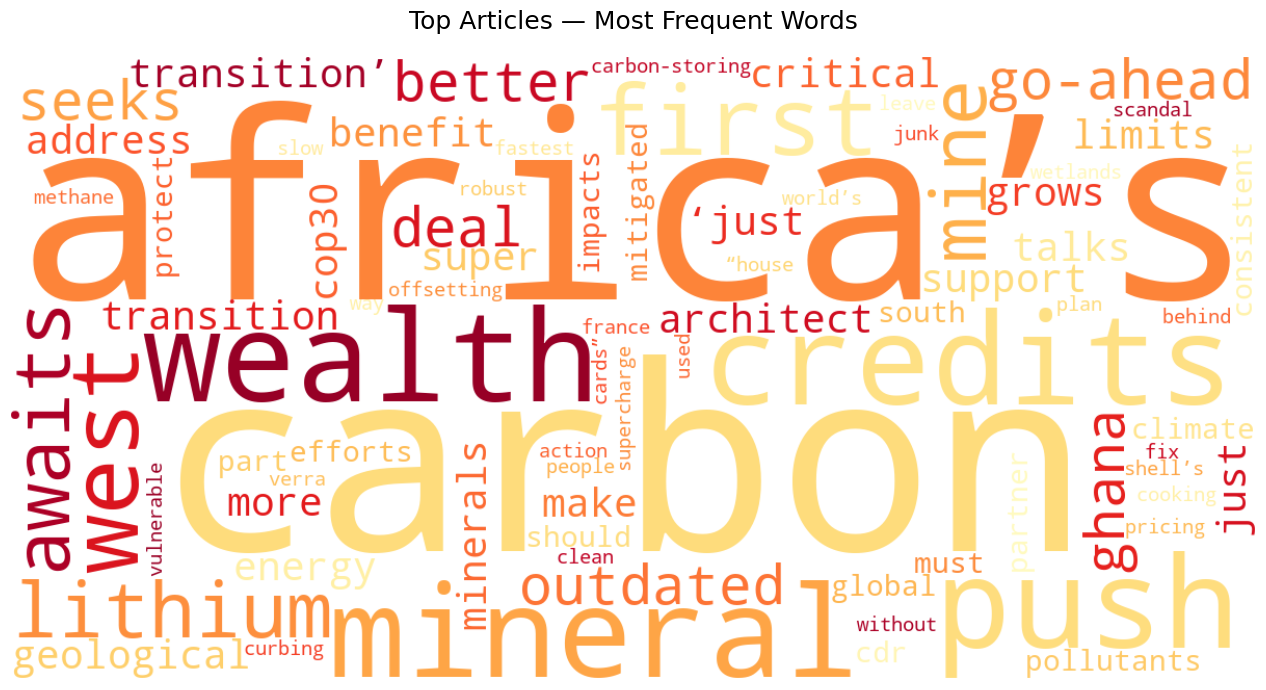


Top 15 words:
  africa’s               3  ███
  carbon                 3  ███
  push                   2  ██
  mineral                2  ██
  wealth                 2  ██
  credits                2  ██
  west                   1  █
  first                  1  █
  lithium                1  █
  mine                   1  █
  awaits                 1  █
  go-ahead               1  █
  ghana                  1  █
  seeks                  1  █
  better                 1  █


In [2]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
%matplotlib inline
# Load data
df = pd.read_csv("scores_final.csv")
df["final_score"] = pd.to_numeric(df["final_score"], errors="coerce").fillna(0).astype(int)

# Top 10 = kept
df = df.sort_values("final_score", ascending=False).reset_index(drop=True)
kept_titles = df.loc[:9, "title"].tolist()

# Stopwords to remove
stopwords = {
    "the", "a", "an", "of", "in", "for", "to", "and", "on", "is", "are",
    "at", "by", "as", "its", "it", "but", "with", "from", "that", "this",
    "be", "or", "not", "has", "have", "was", "were", "will", "can", "could",
    "new", "over", "up", "how", "why", "what", "could", "may", "says",
    "report", "study", "feature", "data", "amid"
}

# Build word frequencies from kept articles
all_words = []
for title in kept_titles:
    words = title.lower().split()
    words = [w.strip(".,:-–()\"'") for w in words]
    words = [w for w in words if w and len(w) > 2 and w not in stopwords]
    all_words.extend(words)

freq = Counter(all_words)

# Word cloud
wc = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="YlOrRd",
    max_words=80,
    min_font_size=12
).generate_from_frequencies(freq)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Top Articles — Most Frequent Words", fontsize=18, pad=20)
plt.tight_layout()
plt.savefig("wordcloud_kept.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 15 words:")
for word, count in freq.most_common(15):
    bar = "█" * count
    print(f"  {word:20s} {count:3d}  {bar}")

---

## ✍️ Étape V — Rédaction automatique de la newsletter

> Les 10 articles retenus sont enrichis avec du **contexte réel** via DuckDuckGo, puis envoyés à Groq (LLM) pour rédiger une newsletter complète **en français**.
>
> Le LLM reçoit pour chaque article : titre + source + résumé web → résumés précis plutôt que devinés.

In [ ]:
import pandas as pd
import os
import time
from litellm import completion
from duckduckgo_search import DDGS

os.environ["GROQ_API_KEY"] = "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"

# Load and get top 10
df = pd.read_csv("scores_final.csv")
df["final_score"] = pd.to_numeric(df["final_score"], errors="coerce").fillna(0).astype(int)
df = df.sort_values("final_score", ascending=False).head(10)

# Search DuckDuckGo for context on each article
print("🔍 Recherche de contexte pour chaque article...\n")
ddgs = DDGS()
articles_text = ""

for i, (_, row) in enumerate(df.iterrows(), 1):
    title = row["title"]
    source = row["source"]
    print(f"[{i}/10] {title[:60]}...")
    
    try:
        results = list(ddgs.text(title, max_results=3))
        snippets = " ".join([r["body"] for r in results]) if results else "Pas de détails disponibles."
    except Exception as e:
        print(f"  ⚠️ Erreur recherche: {str(e)[:50]}")
        snippets = "Pas de détails disponibles."
    
    articles_text += f"""
ARTICLE {i}:
Titre: {title}
Source: {source}
Contexte: {snippets[:500]}
---
"""
    time.sleep(3)

print("\n✍️ Rédaction de la newsletter...\n")

# Ask Groq to write the newsletter
prompt = f"""Tu es un rédacteur spécialisé en énergie et climat en Afrique.
Rédige une newsletter professionnelle en français à partir de ces 10 articles et leur contexte.

{articles_text}

CONSIGNES:
- Titre accrocheur pour la newsletter
- Un paragraphe d'introduction qui résume les tendances de la semaine
- Pour chaque article : un résumé de 2-3 phrases qui explique pourquoi c'est important, en utilisant le contexte fourni
- Mets en avant les articles qui concernent l'Afrique et la Côte d'Ivoire
- Conclus avec une phrase d'ouverture sur les tendances à suivre
- Ton professionnel mais accessible
- Écris TOUT en français
"""

response = completion(
    model="groq/llama-3.1-8b-instant",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.7,
    max_tokens=3000
)

newsletter = response.choices[0].message.content
print(newsletter)

with open("newsletter.md", "w", encoding="utf-8") as f:
    f.write(newsletter)

print("\n💾 Sauvegardé dans newsletter.md")

---

## 📋 Récapitulatif du pipeline

```
titres_extraits.txt ──► scores_llm.csv ──► scores_final.csv ──► lda_model.pkl ──► newsletter.md
     (Étape I)           (Étape II.1)       (Étape II.2+3)     (Étape III)        (Étape V)
   Extraction           LLM Scoring        Web Resonance      Classification     Rédaction
   Crawl4AI             Groq API           DuckDuckGo         Scikit-learn       Groq + DDG
```

| Fichier | Description |
|---------|-------------|
| `extract_all_sites.py` | Script d'extraction multi-sites |
| `titres_extraits.txt` | Titres bruts extraits |
| `scores_llm.csv` | Scores LLM (région + résonance) |
| `scores_final.csv` | Scores finaux avec résonance web |
| `lda_model.pkl` | Modèle LDA sauvegardé |
| `lda_analysis.png` | Visualisation LDA |
| `wordcloud_kept.png` | Nuage de mots des articles retenus |
| `newsletter.md` | Newsletter rédigée en français |

In [3]:
import os
os.chdir(r"C:\Users\p c\Desktop\github-repo\07-News-Async-Crawler")

!git add .
!git commit -m "Update: notebook restructured + scoring pipeline + LDA"
!git push

'git' n’est pas reconnu en tant que commande interne
ou externe, un programme exécutable ou un fichier de commandes.
'git' n’est pas reconnu en tant que commande interne
ou externe, un programme exécutable ou un fichier de commandes.
'git' n’est pas reconnu en tant que commande interne
ou externe, un programme exécutable ou un fichier de commandes.


In [1]:
!git

usage: git [-v | --version] [-h | --help] [-C <path>] [-c <name>=<value>]
           [--exec-path[=<path>]] [--html-path] [--man-path] [--info-path]
           [-p | --paginate | -P | --no-pager] [--no-replace-objects] [--no-lazy-fetch]
           [--no-optional-locks] [--no-advice] [--bare] [--git-dir=<path>]
           [--work-tree=<path>] [--namespace=<name>] [--config-env=<name>=<envvar>]
           <command> [<args>]

These are common Git commands used in various situations:

start a working area (see also: git help tutorial)
   clone      Clone a repository into a new directory
   init       Create an empty Git repository or reinitialize an existing one

work on the current change (see also: git help everyday)
   add        Add file contents to the index
   mv         Move or rename a file, a directory, or a symlink
   restore    Restore working tree files
   rm         Remove files from the working tree and from the index

examine the history and state (see also: git help revisi

In [3]:
!git config --global user.name "Goguenard1"
!git config --global user.email "baji.anas@gmail.com"

In [5]:
import os
os.chdir(r"C:\Users\p c\Desktop\github-repo\07-News-Async-Crawler")

!git init
!git add .
!git commit -m "Newsletter pipeline: extraction, scoring, LDA, NLP, redaction"
!git branch -M main
!git remote add origin https://github.com/Goguenard1/07-News-Async-Crawler.git
!git push -u origin main

Initialized empty Git repository in C:/Users/p c/Desktop/github-repo/07-News-Async-Crawler/.git/


[master (root-commit) 62bcc63] Newsletter pipeline: extraction, scoring, LDA, NLP, redaction
 25 files changed, 10590 insertions(+)
 create mode 100644 .ipynb_checkpoints/Projet_Newsletter-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/Projet_Newsletter_final-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/extract_all_sites-checkpoint.py
 create mode 100644 .ipynb_checkpoints/extract_all_sites_optimized-checkpoint.py
 create mode 100644 .ipynb_checkpoints/extract_all_sites_v2-checkpoint.py
 create mode 100644 .ipynb_checkpoints/extract_v3-checkpoint.py
 create mode 100644 .ipynb_checkpoints/lda_analysis-checkpoint.png
 create mode 100644 .ipynb_checkpoints/lda_scatter-checkpoint.png
 create mode 100644 .ipynb_checkpoints/score_step2_web_resonance-checkpoint.py
 create mode 100644 .ipynb_checkpoints/scores_final-checkpoint.csv
 create mode 100644 .ipynb_checkpoints/scores_final_v2-checkpoint.csv
 create mode 100644 .ipynb_checkpoints/scores_llm-checkpoint.csv
 create mo

remote: Repository not found.
fatal: repository 'https://github.com/Goguenard1/07-News-Async-Crawler.git/' not found


In [ ]:
Desktop/github-repo/07-News-Async-Crawler/Projet_Newsletter_final.ipynb